# Loading Packages

In [212]:
# Linear Algebra
using LinearAlgebra
# File Handling
using Glob, FITSIO, Serialization, HDF5, DelimitedFiles, LibGit2, Suppressor, JLD2, CSV
# Stats
using StatsBase, Distributions, FreqTables, LsqFit, DataStructures, Optim
using BinnedStatistics, KrylovKit, ImageTransformations
import FastRunningMedian: running_median
# Computing
using DataFrames, ProgressMeter, Distributed, PrettyChairmarks, ImageFiltering
using Random, Interpolations, SparseArrays, EllipsisNotation, ShiftedArrays, ParallelDataTransfer
# Astro
using Healpix, SkyCoords, WCS, AstroTime, DustExtinction
# String Formatting
using LaTeXStrings
# Plotting
using CairoMakie; set_theme!(theme_black()); CairoMakie.disable_mime!("svg", "pdf", "text/html");
using ColorSchemes

# To Do
- function to generate spectrum given parameters/symmetry/active axes
    - submit pgo and pgo epsilon temp [x]
    - convolve spectrum [x]
    - optimize linear scaling parameters [x]
- function for the likelihood [x]
- implement rovibrational coupling and km/s broadening (after dinner) [x]
- [how am I handling Cs TDM combinations, template and linear algebra, but later]
- fit 15672
- do gradient descent
- implement true LSF

In [2]:
function replace_multiple(str, replacements)
    for pair in replacements
        str = replace(str, pair)
    end
    str
end

fwhm2sigma = 1 / (2 * sqrt(2 * log(2)))

function lsf_sigma(λ, R)
    return (λ / R) * fwhm2sigma
end

function lsf_sigma_and_bounds(λ, R; σ_window=10)
    σ = lsf_sigma(λ, R)
    return σ, (λ - σ_window * σ, λ + σ_window * σ)
end

function instrumental_lsf_kernel(λ, λc, R)
    σ, (lower, upper) = lsf_sigma_and_bounds(λc, R)
    msk = (lower .<= λ .<= upper)
    ϕ = exp.(-((λ[msk] .- λc).^2) / (2σ^2))
    ϕ ./= dropdims(sum(ϕ, dims=1), dims=1)
    return msk, ϕ
end

function instrument_lsf_sparse_matrix(λ_input, λ_output, R)
    row, col, val = Int[], Int[], Float64[]
    @showprogress for (indx, λ) in enumerate(λ_output)
        msk, ϕ = instrumental_lsf_kernel(λ_input, λ, R)
        push!(row, fill(indx, count(msk))...)
        push!(col, findall(msk)...)
        push!(val, ϕ...)
    end
    return sparse(row, col, val)
end

instrument_lsf_sparse_matrix (generic function with 1 method)

In [32]:
pgo_path = "/uufs/chpc.utah.edu/common/home/u6039752/scratch1/software/pgo/pgo"
template_path = "/uufs/chpc.utah.edu/common/home/u6039752/scratch1/working/2025_10_02/asym_top_15672_C2v.pgo"
examp_out_path = replace(template_path,".pgo"=>".out");

In [33]:
run(`$(pgo_path) --plot $(template_path) $(replace(template_path,".pgo"=>".out"))`)

Process(`/uufs/chpc.utah.edu/common/home/u6039752/scratch1/software/pgo/pgo --plot /uufs/chpc.utah.edu/common/home/u6039752/scratch1/working/2025_10_02/asym_top_15672_C2v.pgo /uufs/chpc.utah.edu/common/home/u6039752/scratch1/working/2025_10_02/asym_top_15672_C2v.out`, ProcessExited(0))

In [34]:
out = readdlm(examp_out_path)
wavenum_pgo = out[:,1] # invcm
waveAng_pgo = 1e8 ./wavenum_pgo;

In [267]:
bal_errors = true
emphasize_dT_center = true

f = h5open("/uufs/chpc.utah.edu/common/home/u6039752/scratch/zenodo/RvDIBs/jackknife_plates_dib_15673.h5")
dib_wave = read(f["wave"])
dib_mean = read(f["mean"])
dib_var = read(f["var"])
close(f)

if bal_errors
    direct_min, direct_max = extrema(dib_mean[1,:])
    direct_noise_med = median(sqrt.(dib_var[1,:]))
    direct_rel_err = direct_noise_med/abs(direct_max-direct_min)

    dT_min, dT_max = extrema(dib_mean[2,:])
    dT_noise_med = median(sqrt.(dib_var[2,:]))
    dT_rel_err = dT_noise_med/abs(dT_max-dT_min)

    dib_var[1,:].*= (dT_rel_err/direct_rel_err)^2
end

if emphasize_dT_center
    width = 7
    emphasize_fac = 3
    center_idx = size(dib_mean,2)÷2
    dib_var[2,(center_idx-width):(center_idx+width)]./=emphasize_fac
end
println("Data Loaded")

Data Loaded


In [36]:
dib_wave_temp = vcat(minimum(waveAng_pgo), dib_wave, maximum(waveAng_pgo));

In [37]:
# Rf = 1/sqrt(1/22_500^2 + 1/(3e5/23)^2) # moved into the PGO call
Lsf = instrument_lsf_sparse_matrix(waveAng_pgo, dib_wave_temp, 22_500);

Progress: 100%|█████████████████████████████████████████| Time: 0:00:01


In [258]:
include("xml_editor.jl")
function synthesize_spec(;Aval=0.07,Bval=0.01,Cval=0.01,alpha_A=1.0,alpha_B=1.0,alpha_C=1.0,
        Tval=7,epsT=0.05,sig_v=23,delnu=0,
        c=299792.458 # km/s speed of light
    )
    
    pgo_path = "/uufs/chpc.utah.edu/common/home/u6039752/scratch1/software/pgo/pgo"
    template_path = "/uufs/chpc.utah.edu/common/home/u6039752/scratch1/working/2025_10_02/asym_top_15672_C2v.pgo"
    examp_out_path = replace(template_path,".pgo"=>".out")
    temp_dir = "./pgo_temp/"
    if !isdir(temp_dir)
        mkpath(temp_dir)
    end
    temp_path = tempname(temp_dir)
    
    editor = load_xml(template_path)
    cen_nu = parse(Float64, get_parameter(editor, "Species.AsymmetricTop.Excited.v=1.Origin"))
    Rdop = c/(sig_v/fwhm2sigma)
    dnu = cen_nu/Rdop
    
    set_parameter!(editor, "Temperature", "$(Tval)")
    set_parameter!(editor, "Lorentzian", "$(dnu)")
    # set_parameter!(editor, "Gaussian", "$(dnu)")
    set_parameter!(editor, "Species.AsymmetricTop.Ground.v=0.A", "$(Aval)")
    set_parameter!(editor, "Species.AsymmetricTop.Ground.v=0.B", "$(Bval)")
    set_parameter!(editor, "Species.AsymmetricTop.Ground.v=0.C", "$(Cval)")
    set_parameter!(editor, "Species.AsymmetricTop.Excited.v=1.Origin", "$(cen_nu+delnu)")
    set_parameter!(editor, "Species.AsymmetricTop.Excited.v=1.A", "$(alpha_A*Aval)")
    set_parameter!(editor, "Species.AsymmetricTop.Excited.v=1.B", "$(alpha_B*Bval)")
    set_parameter!(editor, "Species.AsymmetricTop.Excited.v=1.C", "$(alpha_C*Cval)")
    save_xml(editor, save_path=temp_path*".pgo")
    
    editor = load_xml(template_path)
    set_parameter!(editor, "Temperature", "$(Tval+epsT)")
    set_parameter!(editor, "Lorentzian", "$(dnu)")
    # set_parameter!(editor, "Gaussian", "$(dnu)")
    set_parameter!(editor, "Species.AsymmetricTop.Ground.v=0.A", "$(Aval)")
    set_parameter!(editor, "Species.AsymmetricTop.Ground.v=0.B", "$(Bval)")
    set_parameter!(editor, "Species.AsymmetricTop.Ground.v=0.C", "$(Cval)")
    set_parameter!(editor, "Species.AsymmetricTop.Excited.v=1.Origin", "$(cen_nu+delnu)")
    set_parameter!(editor, "Species.AsymmetricTop.Excited.v=1.A", "$(alpha_A*Aval)")
    set_parameter!(editor, "Species.AsymmetricTop.Excited.v=1.B", "$(alpha_B*Bval)")
    set_parameter!(editor, "Species.AsymmetricTop.Excited.v=1.C", "$(alpha_C*Cval)")
    save_xml(editor, save_path=temp_path*"_dT.pgo")

    run(`$(pgo_path) --plot $(temp_path).pgo $(temp_path).out`)
    run(`$(pgo_path) --plot $(temp_path)_dT.pgo $(temp_path)_dT.out`)
    
    out = readdlm(temp_path*".out")
    flux = (Lsf*out[:,2])[2:end-1];

    out = readdlm(temp_path*"_dT.out")
    flux_dT = (Lsf*out[:,2])[2:end-1];

    flux_diff = (flux_dT.-flux)./epsT;
    # rm(temp_path*".pgo")
    # rm(temp_path*"_dT.pgo")
    # rm(temp_path*".out")
    # rm(temp_path*"_dT.out")
    return flux, flux_diff
end

synthesize_spec (generic function with 1 method)

In [259]:
# should this include possible velocity shifts?
# this might become nonlinear when we want to learn the A/B TDM ratio (inner part still linear)
function optimize_meta_params(dib_ext, dib_ext_var, dib_Rv, dib_Rv_var, flux, flux_diff)
    Md = zeros(length(flux),2)
    Md[:,1].=flux
    Md[:,2].=1
    W = Diagonal(1 ./ dib_ext_var);

    extinct_cons_coeff = (Md'*(W*Md))\(Md'*(W*dib_ext))

    M = zeros(length(flux),3)
    M[:,1].=flux
    M[:,2].=flux_diff
    M[:,3].=1
    W = Diagonal(1 ./ dib_Rv_var);

    Rv_cons_coeff = (M'*(W*M))\(M'*(W*dib_Rv));
    return (extinct_cons_coeff, Md), (Rv_cons_coeff, M)
end

optimize_meta_params (generic function with 1 method)

In [260]:
function compute_chi2(extinct_tup, Rv_tup, dib_ext, dib_ext_var, dib_Rv, dib_Rv_var; return_resid=false, return_per_component=false)
    model_extinct = extinct_tup[2]*extinct_tup[1]
    res_extinct = (dib_ext.-model_extinct)./sqrt.(dib_ext_var)
    chi2_extinct = sum(res_extinct.^2)
    dof_extinct = length(model_extinct)-length(extinct_tup[1])
    
    model_Rv = Rv_tup[2]*Rv_tup[1]
    res_Rv = (dib_Rv.-model_Rv)./sqrt.(dib_Rv_var)
    chi2_Rv = sum(res_Rv.^2)
    dof_Rv = length(model_extinct)-length(extinct_tup[1])
    
    if return_resid
        return vcat(res_extinct,res_Rv)
    end
    
    if return_per_component
        return (chi2_extinct + chi2_Rv)/(dof_extinct + dof_Rv), chi2_extinct/dof_extinct, chi2_Rv/dof_Rv
    else
        return (chi2_extinct + chi2_Rv)/(dof_extinct + dof_Rv)
    end
end

compute_chi2 (generic function with 1 method)

In [261]:
using Optim

In [262]:
function nonlinear_lsq_fun(u)
    A, B, C, alphaA, alphaB, alphaC, T, sigv = u
    flux, flux_diff = synthesize_spec(Aval = A, Bval = B, Cval = C, Tval = T, 
        alpha_A = alphaA, alpha_B = alphaB, alpha_C = alphaC, sig_v=sigv, epsT = 0.05)
    extinct_tup, Rv_tup = optimize_meta_params(dib_mean[1,:], dib_var[1,:], dib_mean[2,:], dib_var[2,:], flux, flux_diff)
    chi2 = compute_chi2(extinct_tup, Rv_tup, dib_mean[1,:], dib_var[1,:], dib_mean[2,:], dib_var[2,:])
    return chi2
end

nonlinear_lsq_fun (generic function with 1 method)

In [263]:
# lower = [0.0001, 0.0001, 0.0001, 0.0001]
# upper = [1, 1, 1, 100]
# initial_x = [0.001,0.001,0.063,4]
# result = optimize(nonlinear_lsq_fun, lower, upper, initial_x, Fminbox(LBFGS()), Optim.Options(show_trace=true))

In [264]:
# opt_params = Optim.minimizer(result)

In [265]:
function nonlinear_lsq_fun_final(u)
    A, B, C, alphaA, alphaB, alphaC, T, sigv, delnu = u
    flux, flux_diff = synthesize_spec(Aval = A, Bval = B, Cval = C, Tval = T, 
        alpha_A = alphaA, alpha_B = alphaB, alpha_C = alphaC, sig_v=sigv, delnu=delnu, epsT = 0.05)
    extinct_tup, Rv_tup = optimize_meta_params(dib_mean[1,:], dib_var[1,:], dib_mean[2,:], dib_var[2,:], flux, flux_diff)
    chi2_tot, chi2_extinct, chi2_Rv = compute_chi2(extinct_tup, Rv_tup, dib_mean[1,:], dib_var[1,:], dib_mean[2,:], dib_var[2,:],return_per_component=true)
    println((chi2_tot, chi2_extinct, chi2_Rv))
    return extinct_tup, Rv_tup
end

nonlinear_lsq_fun_final (generic function with 1 method)

(0.8806720083380188, 0.4243801561565323, 1.3369638605195056)


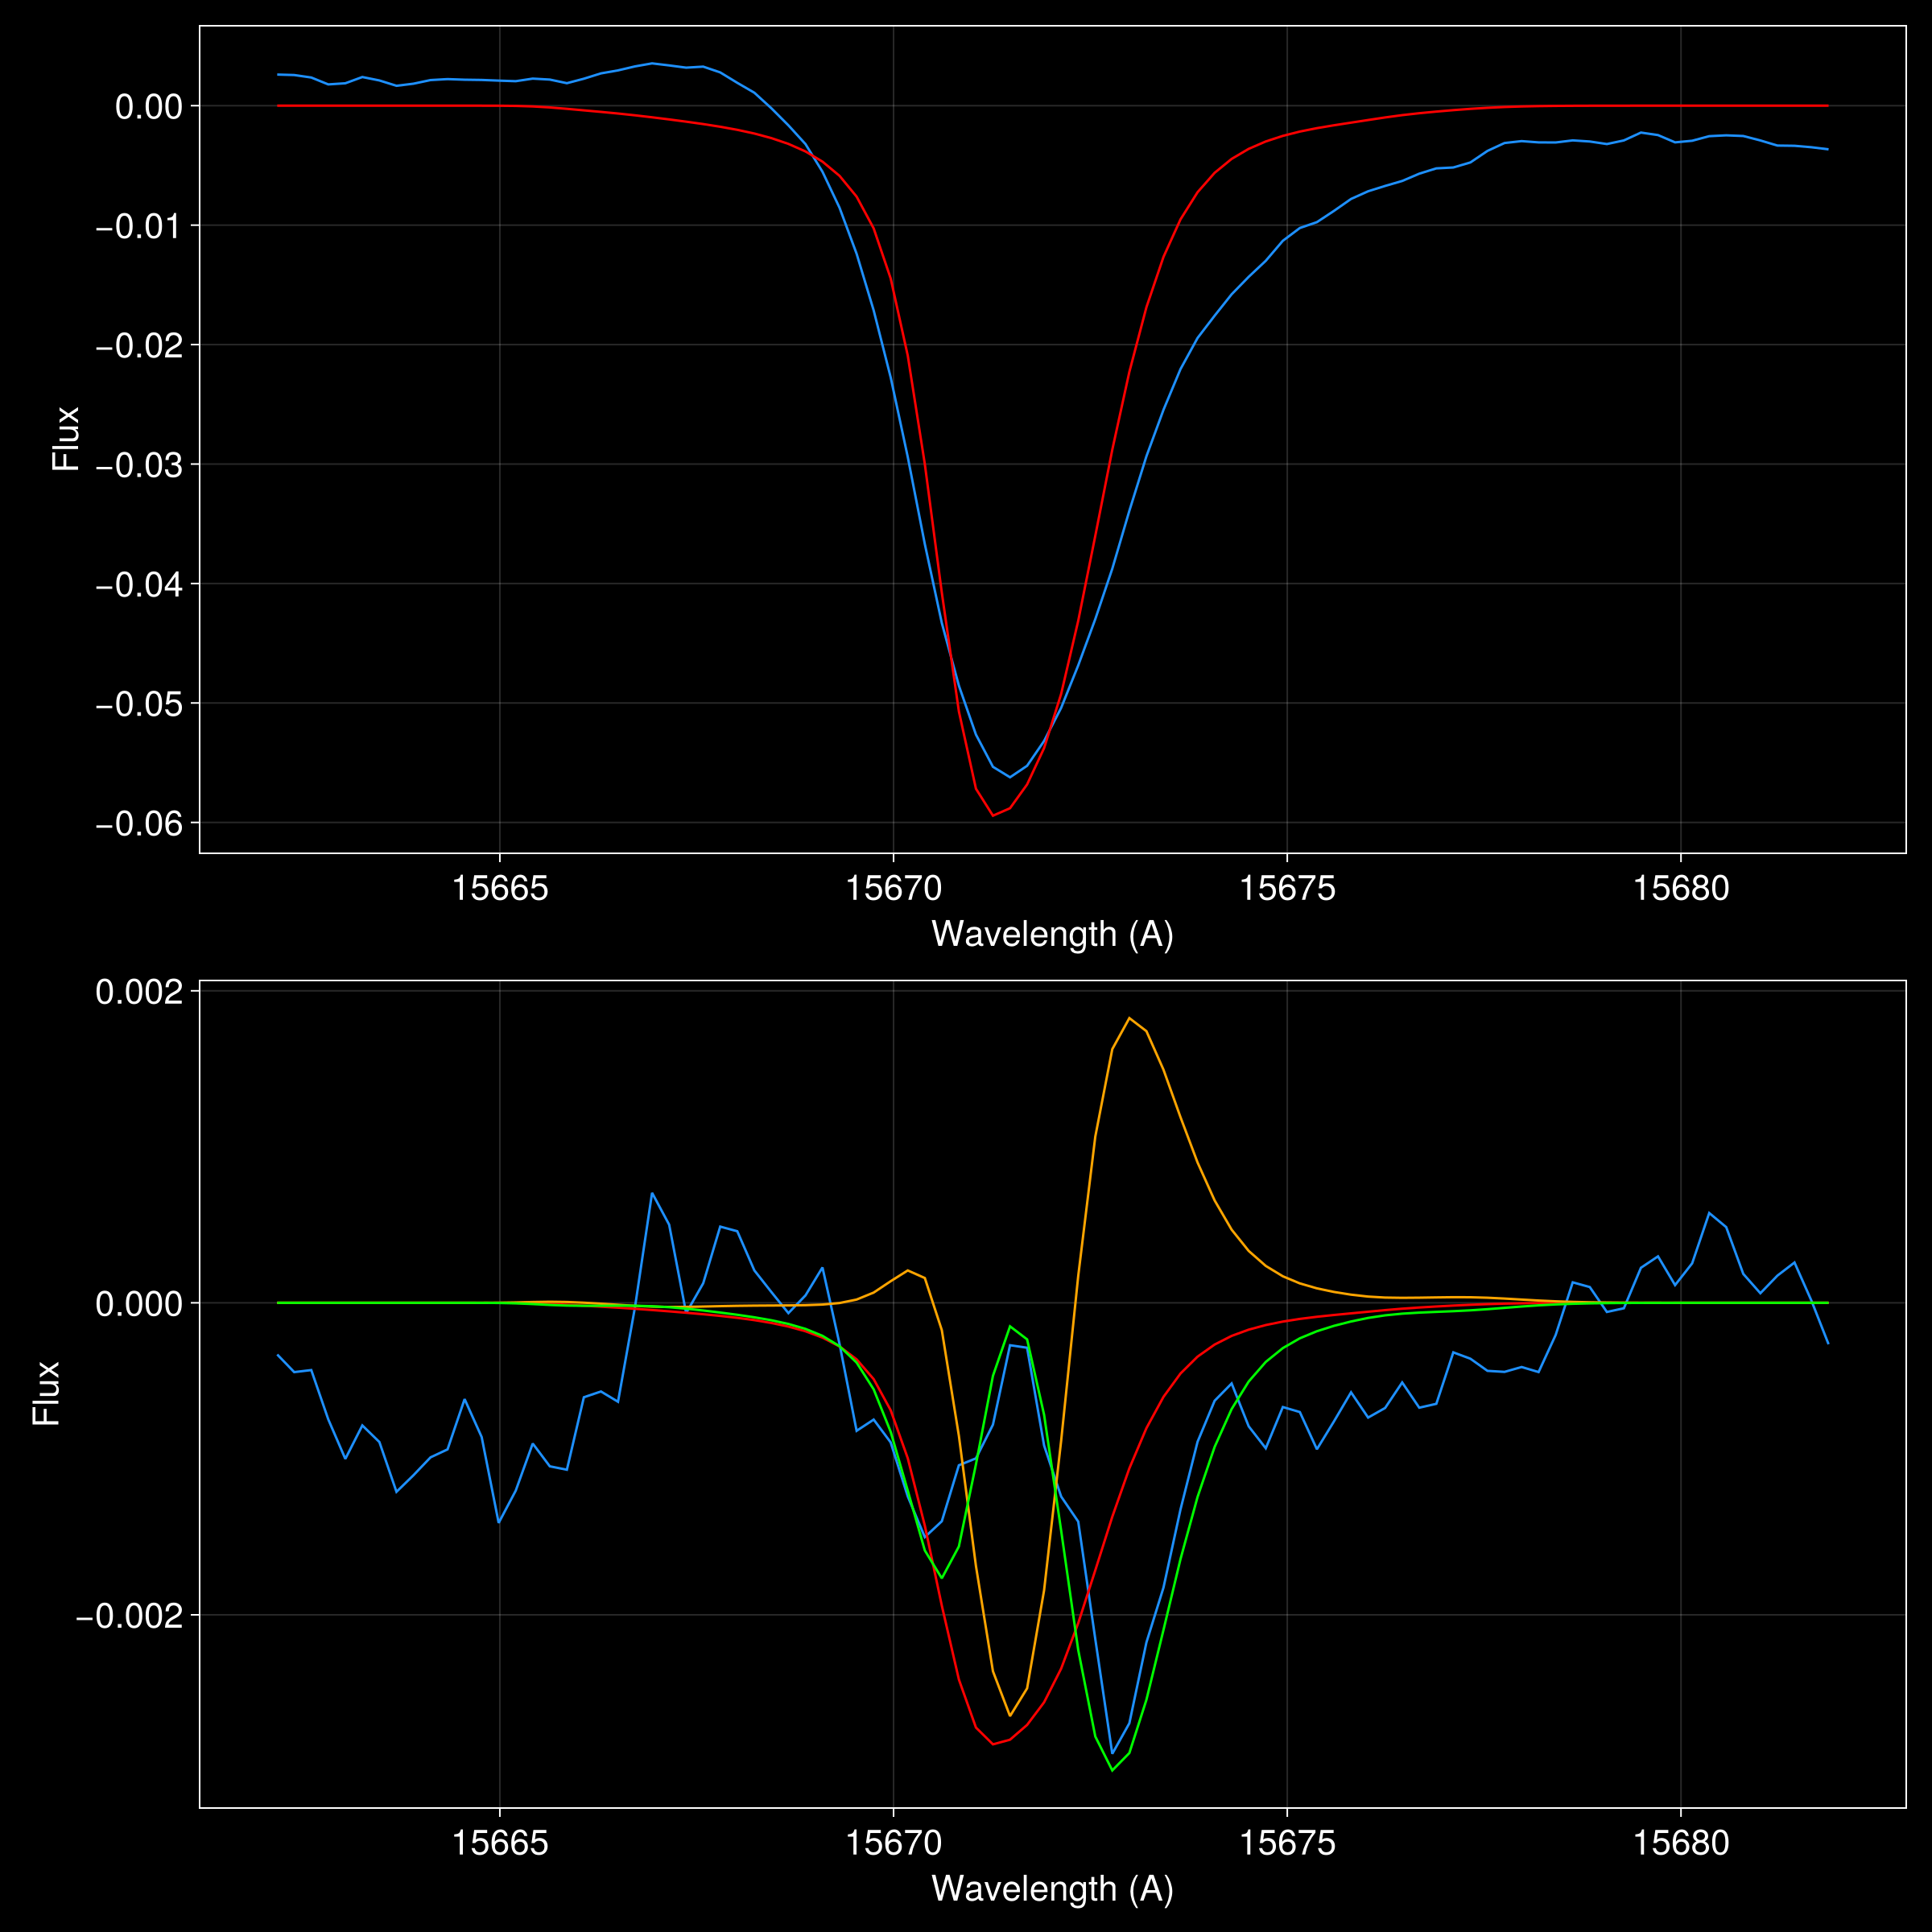

In [271]:
# christian points out that this works for 15272 for C2v (with alphas, but even without a lot of lifetime)
# why does that part of parameter space work so well???
# I also wanted to think about isotopologues
extinct_tup, Rv_tup = nonlinear_lsq_fun_final([0.04,0.0035,0.0035,0.98,0.99,0.99,7,7,0.05]);

fig = Figure(size=(1200, 1200), fontsize=22)
ax = Axis(fig[1, 1],
    xlabel="Wavelength (A)",
    ylabel="Flux",
)

co = lines!(ax,dib_wave,dib_mean[1,:],color="dodgerblue")
# co = lines!(ax,dib_wave,extinct_tup[2]*extinct_tup[1],color="limegreen")
co = lines!(ax,dib_wave,-0.21*extinct_tup[2][:,1],color="red")
# co = lines!(ax,dib_wave,0.0*extinct_tup[2][:,2],color="yellow")

ax = Axis(fig[2, 1],
    xlabel="Wavelength (A)",
    ylabel="Flux",
)

co = lines!(ax,dib_wave,dib_mean[2,:],color="dodgerblue")
# co = lines!(ax,dib_wave,Rv_tup[2]*Rv_tup[1],color="limegreen")
co = lines!(ax,dib_wave,-0.01*Rv_tup[2][:,1],color="red")
co = lines!(ax,dib_wave,0.21*Rv_tup[2][:,2],color="orange")
co = lines!(ax,dib_wave,-0.01*Rv_tup[2][:,1].-0.21*Rv_tup[2][:,2],color="lime")
# co = lines!(ax,dib_wave,0.0*Rv_tup[2][:,3],color="yellow")

resize_to_layout!(fig)
fig

### (a) - (b,c) controls the width of the dT peaks ?
- at the very smallest part of the range, we don't get double peaks, we go from +-+ to -+ to just -
- can use this just - to create the correct structure in Rv, but just need to tune the shfit, separation, and asymmetry
- a very large alpha on one of the small axes, can give you a nice tail (but like 20%, which seems a lot?)

(1.3824239905881774, 0.3146358046708616, 2.4502121765054934)


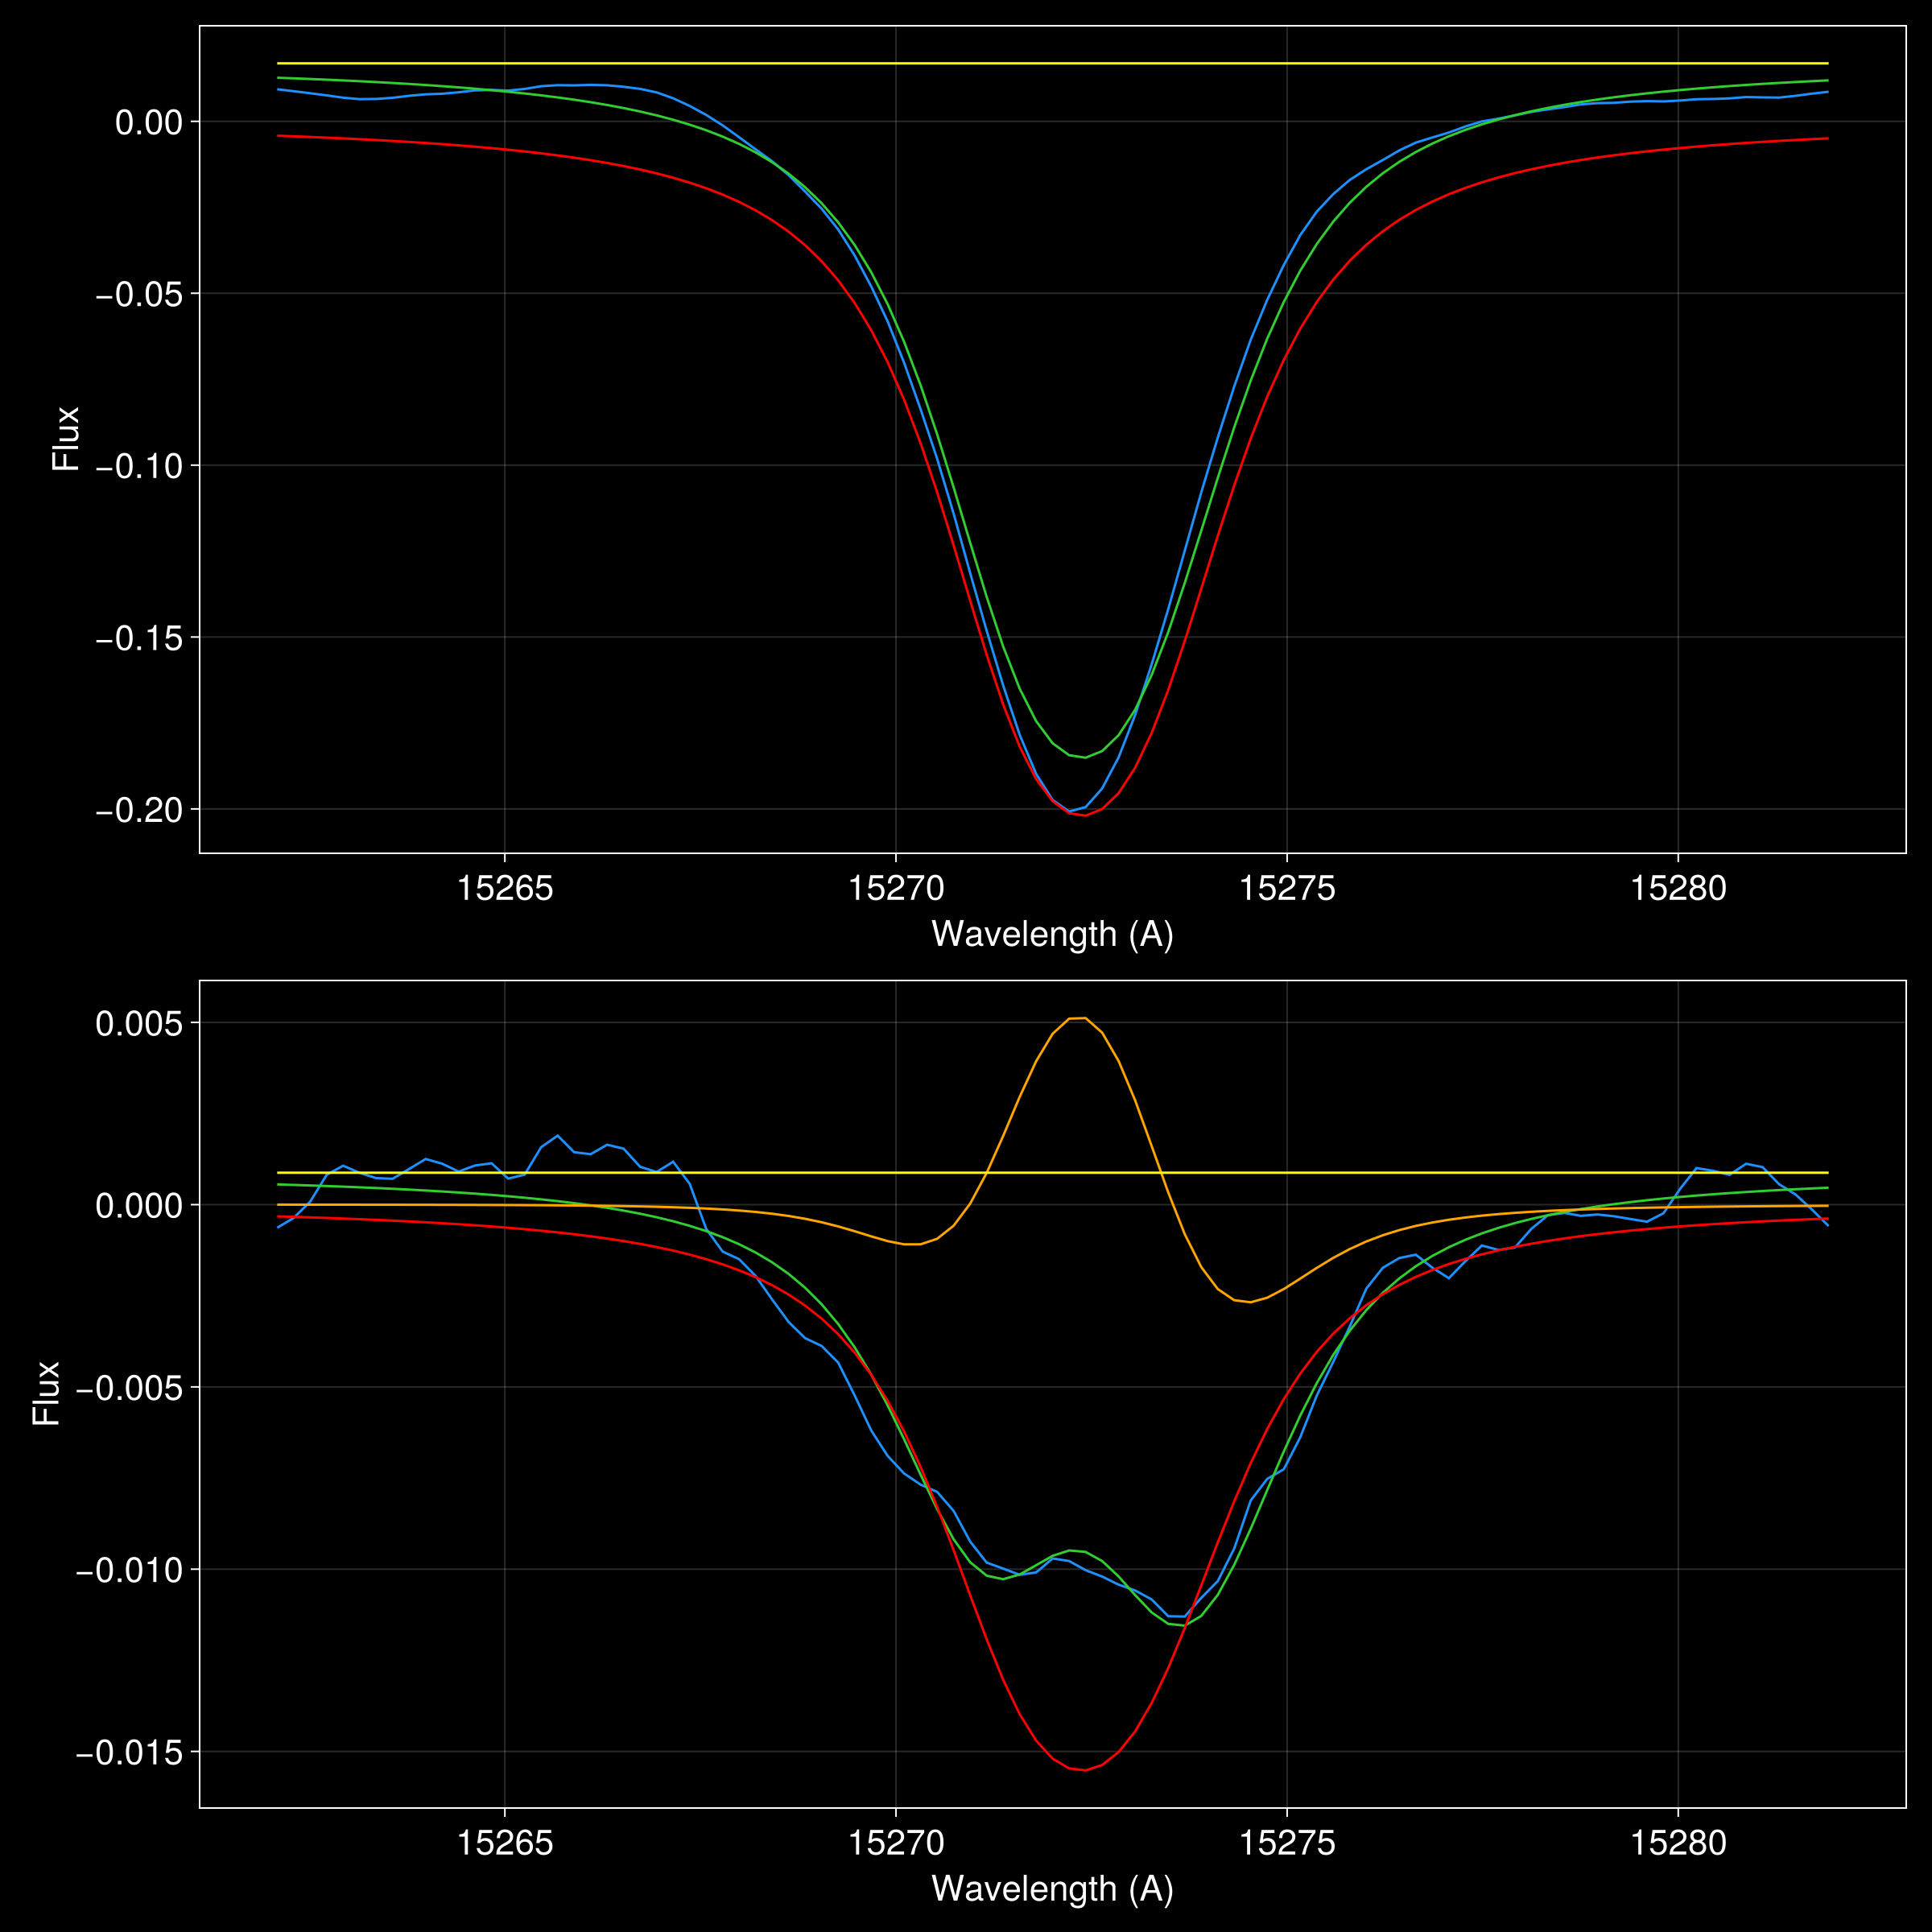

In [17]:
# christian points out that this works for 15272 for C2v (with alphas, but even without a lot of lifetime)
# why does that part of parameter space work so well???
# I also wanted to think about isotopologues
extinct_tup, Rv_tup = nonlinear_lsq_fun_final([0.065,0.005,0.005,0.98846,0.99784,0.9996,9.877,21]);

fig = Figure(size=(1200, 1200), fontsize=22)
ax = Axis(fig[1, 1],
    xlabel="Wavelength (A)",
    ylabel="Flux",
)

co = lines!(ax,dib_wave,dib_mean[1,:],color="dodgerblue")
co = lines!(ax,dib_wave,extinct_tup[2]*extinct_tup[1],color="limegreen")
co = lines!(ax,dib_wave,extinct_tup[1][1]*extinct_tup[2][:,1],color="red")
co = lines!(ax,dib_wave,extinct_tup[1][2]*extinct_tup[2][:,2],color="yellow")

ax = Axis(fig[2, 1],
    xlabel="Wavelength (A)",
    ylabel="Flux",
)

co = lines!(ax,dib_wave,dib_mean[2,:],color="dodgerblue")
co = lines!(ax,dib_wave,Rv_tup[2]*Rv_tup[1],color="limegreen")
co = lines!(ax,dib_wave,Rv_tup[1][1]*Rv_tup[2][:,1],color="red")
co = lines!(ax,dib_wave,Rv_tup[1][2]*Rv_tup[2][:,2],color="orange")
co = lines!(ax,dib_wave,Rv_tup[1][3]*Rv_tup[2][:,3],color="yellow")

resize_to_layout!(fig)
fig

this then depends on alpha... but I don't see how this is going to work for the 15672 DIB